# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Anh Bach

**Date:** 9/10/2026

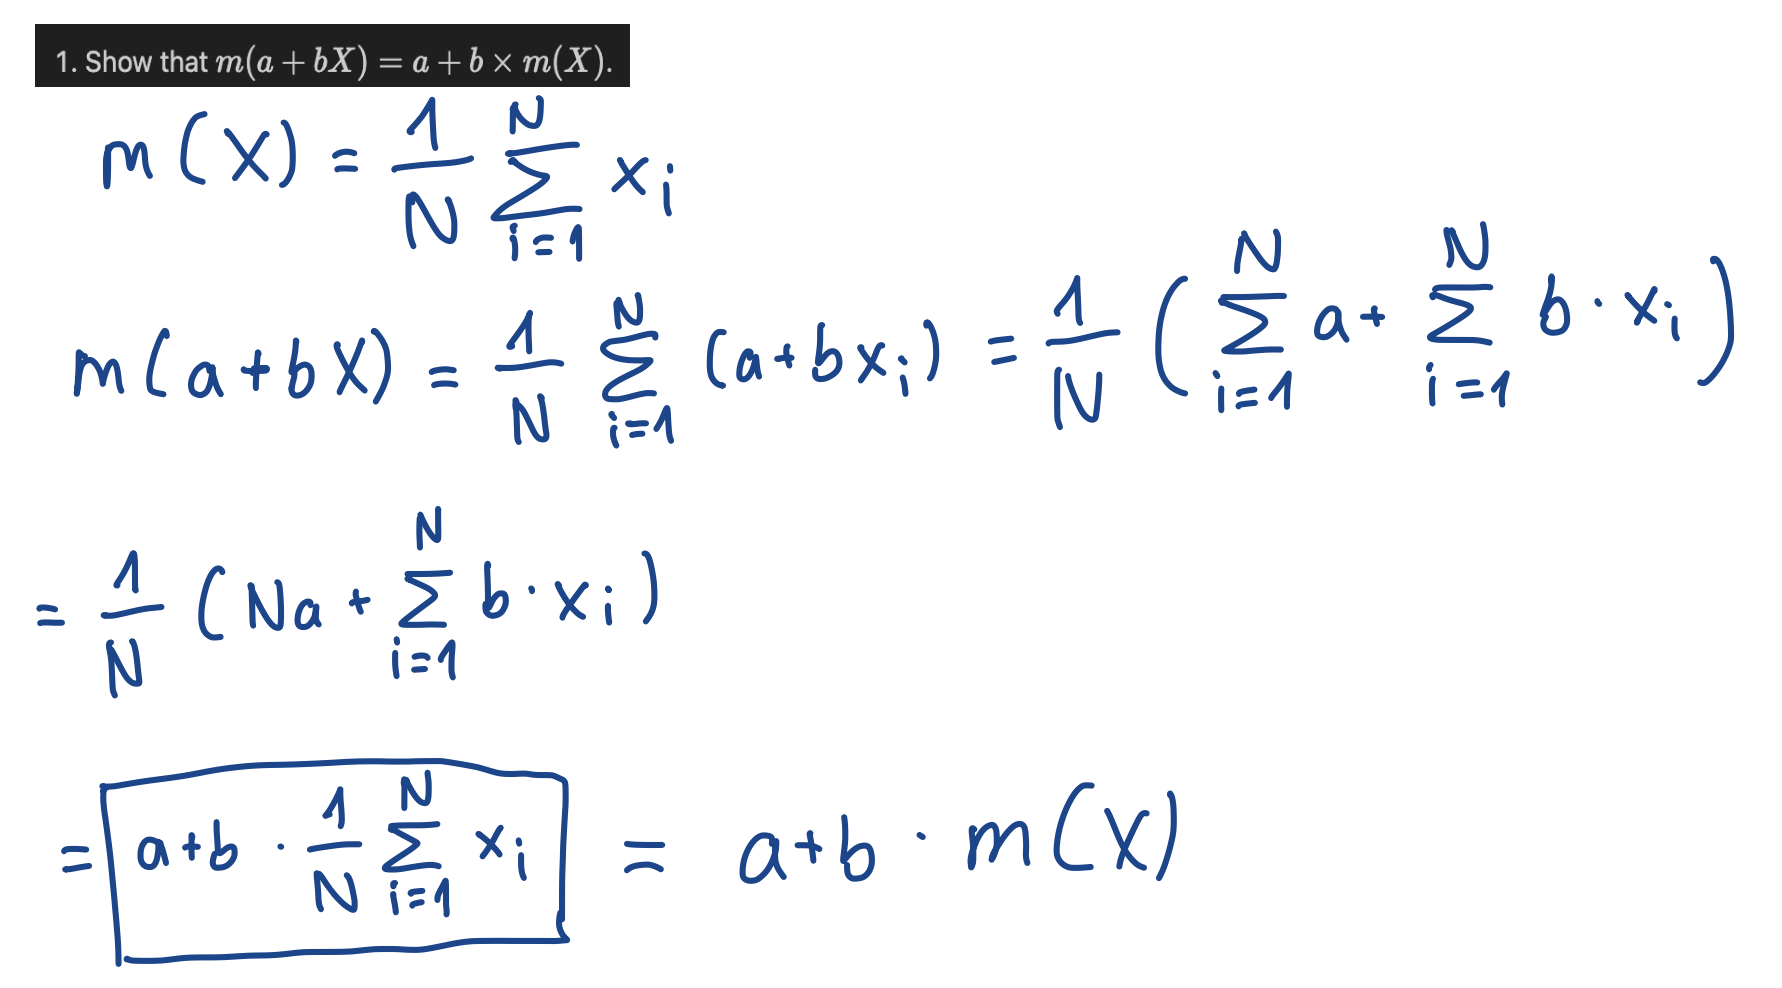

In [1]:
# Your Phase 1 solution to the problem goes here.

#Q1-1
from IPython.display import Image
Image("images/q1.1.png")

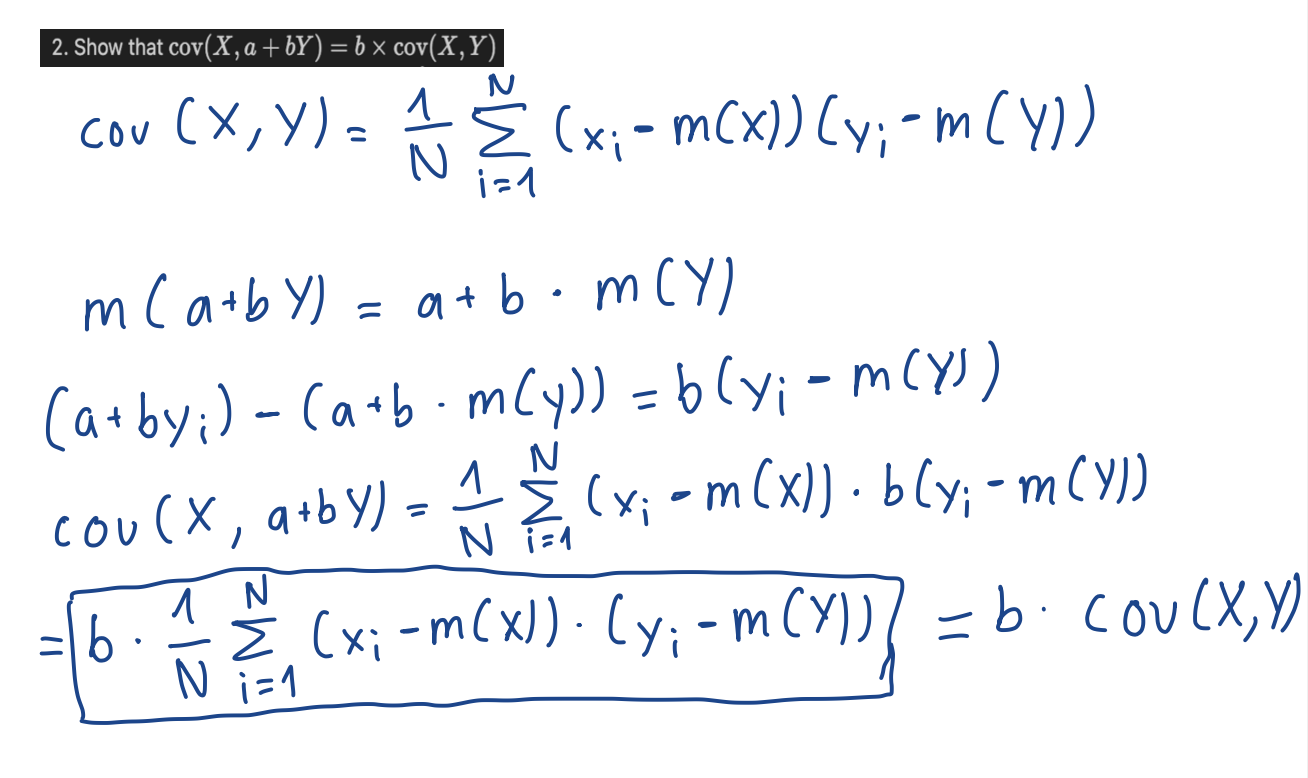

In [2]:
#Q1-2
Image("images/q1.2.png")

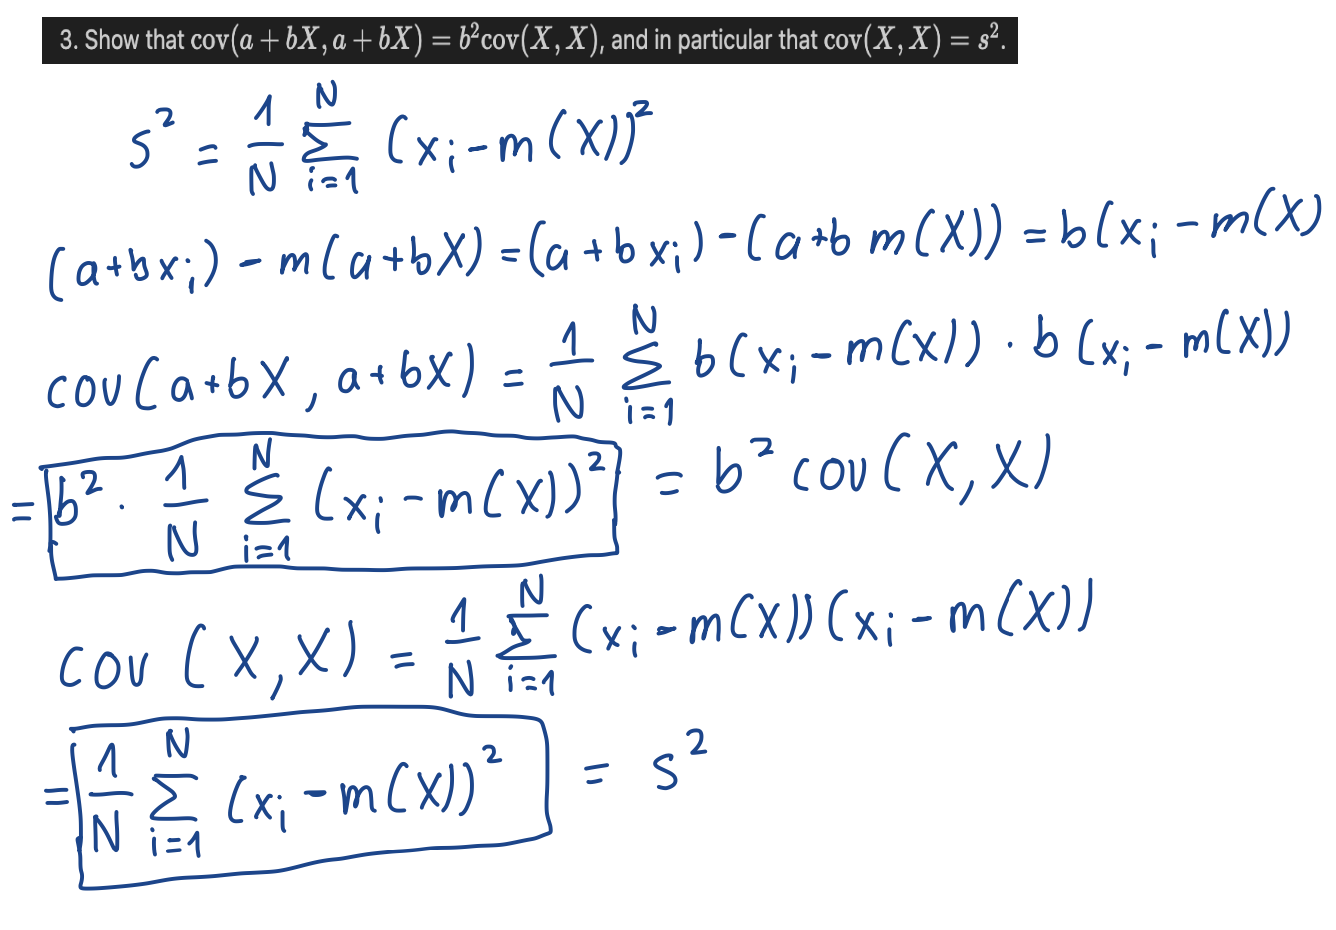

In [3]:
#Q1-3
Image("images/q1.3.png")

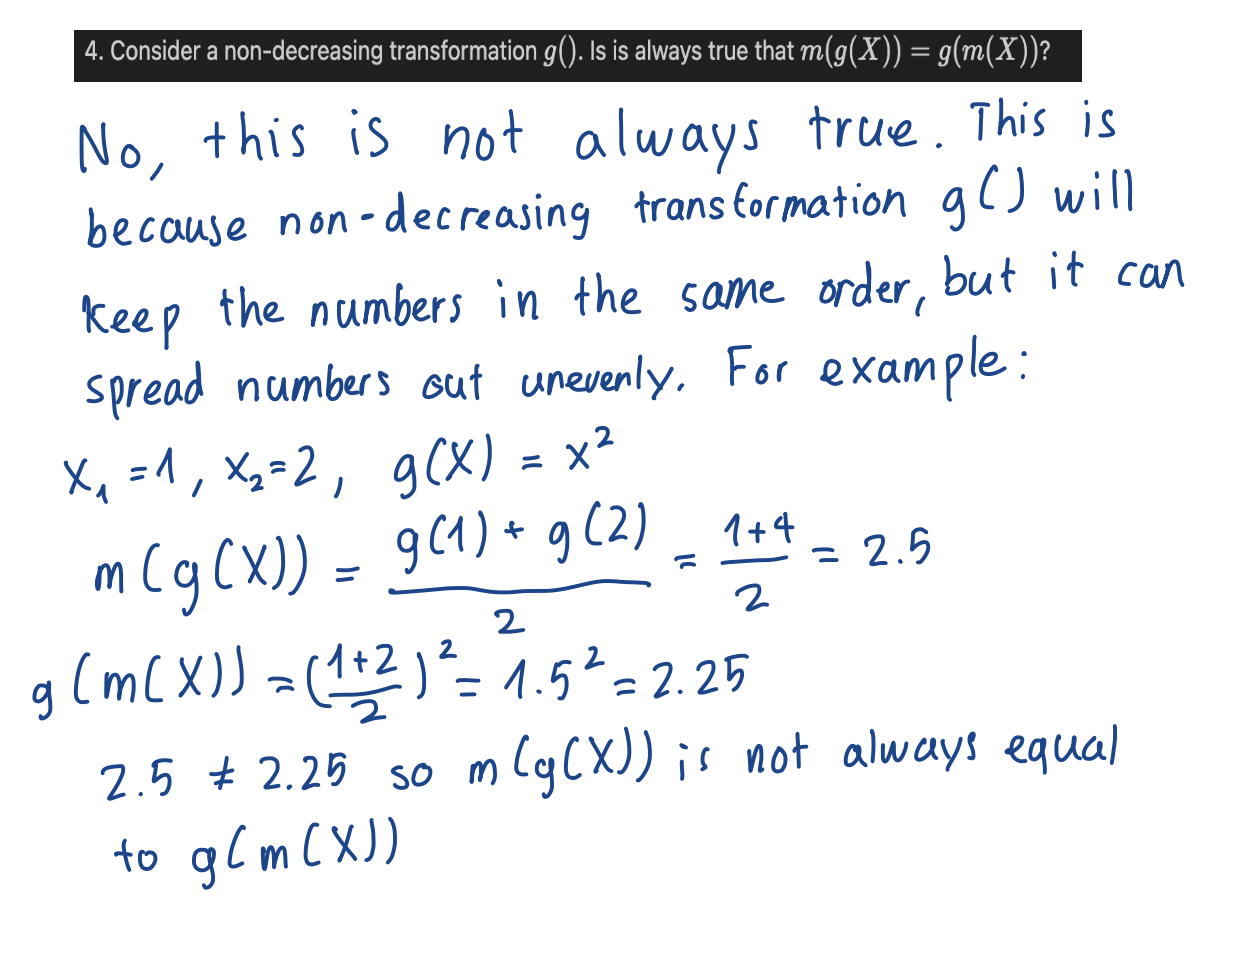

In [4]:
#Q1-4
Image("images/q1.4.png")

In [5]:
#Q2 Code 

#Q2-1 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./data/ForeignGifts_edu.csv")
df["Foreign Gift Amount"].describe()

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64

Q2-1 Answer: There are 28,221 gifts with a range of -$537,770 to $100,000,000, a median of about $94,615, and a mean of about $588,233. The mean sitting so far above the median means a small number of very large gifts are pulling the average up.

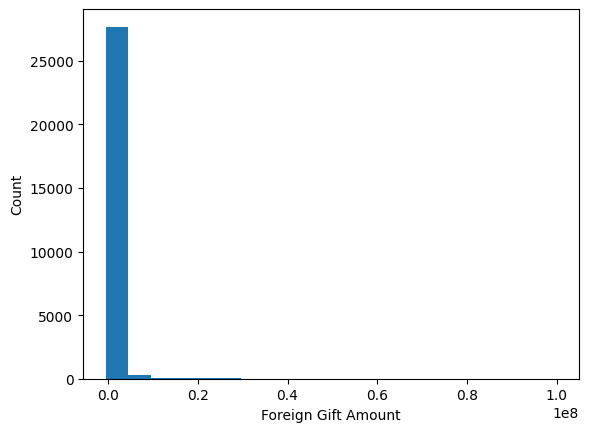

In [6]:
#Q2-2 
df["Foreign Gift Amount"].hist(bins=20, grid=False)
plt.xlabel("Foreign Gift Amount")
plt.ylabel("Count")
plt.show()

Q2-2 Answer: Most of the gifts are small with a few very large ones. Almost all of them are in the first bar, showing that most gifts are under $5 million. The axis covers all the way to $100 million, which appears to be the largest gift. As such, the histogram is extremely right skewed, and not really easy to read.

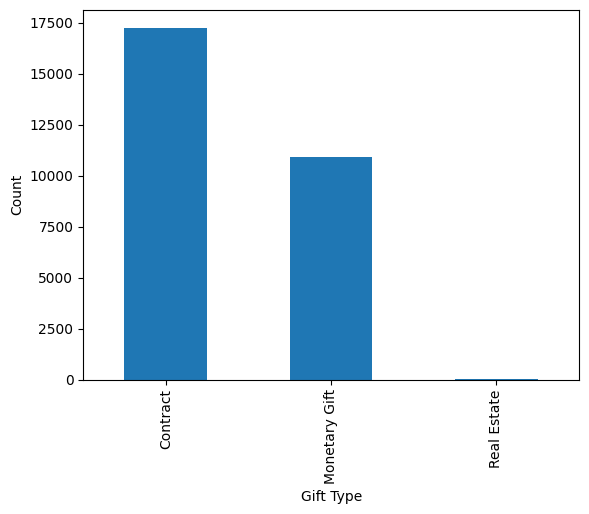

Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64

In [7]:
#Q2-3
df["Gift Type"].value_counts().plot(kind="bar")
plt.xlabel("Gift Type")
plt.ylabel("Count")
plt.show()

df["Gift Type"].value_counts(normalize=True)

Q2-3 Answer: Contracts make up about 61.2% of the gifts and monetary gifts make up about 38.75%. Real estate has very few records, which is about 0.04%.

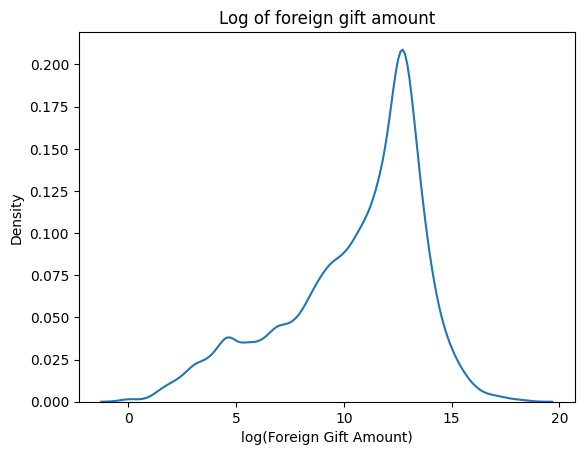

In [8]:
#Q2-4
transformation = df[df["Foreign Gift Amount"] > 0].copy()
transformation["log_amount"] = np.log(transformation["Foreign Gift Amount"])

#kernel density plot of the log of Foreign Gift Amount
sns.kdeplot(data=transformation, x="log_amount")
plt.title("Log of foreign gift amount")
plt.xlabel("log(Foreign Gift Amount)")
plt.show()

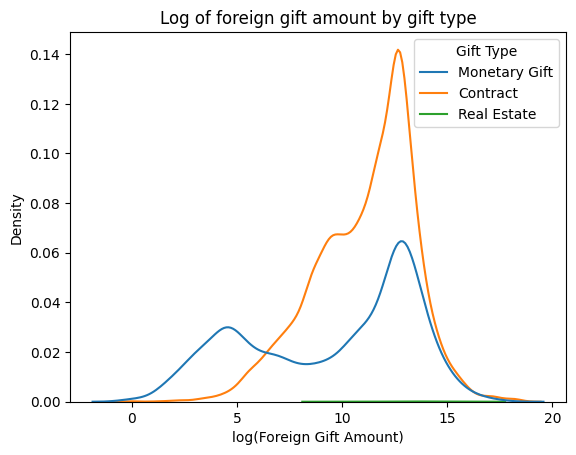

In [9]:
#kernel density plot of the log of Foreign Gift Amount by type
sns.kdeplot(data=transformation, x="log_amount", hue="Gift Type")
plt.title("Log of foreign gift amount by gift type")
plt.xlabel("log(Foreign Gift Amount)")
plt.show()

Q2-4 Answer: Taking the log makes the data much easier to read. The density plot shows one big peak around 13, a long tail to the left, and a peak around 4.5 where the smaller gifts are. When split by gift type, contracts have one large peak in the same place at around 13, while monetary gifts are split into two peaks one around 4.5 and another around 13. This shows that monetary gifts are either very small or fairly large with less in between. Real estate is just a flat line along the bottom because there are few observations compared to other gift types. 

In [10]:
#Q2-5
df.groupby("Country of Giftor")["Foreign Gift Amount"].count().sort_values(ascending=False).head(15)

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64

In [11]:
df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(15)

Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64

Q2-5 Answer: By number of gifts, the top 15 countries are England, China, Canada, Japan, Switzerland, Saudi Arabia, France, Germany, Hong Kong, South Korea, Qatar, the Netherlands, Korea, India, and Taiwan. 
By total amount given, the top 15 are Qatar, England, China, Saudi Arabia, Bermuda, Canada, Hong Kong, Japan, Switzerland, India, Germany, the United Arab Emirates, France, Singapore, and Australia.

In [12]:
#Q2-6
df.groupby("Giftor Name")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(15)

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64

Q2-6 Answer: The top three giftors are Qatar Foundation at about $1.17 billion, Qatar Foundation/Qatar National Res at about $796 million, and Qatar Foundation for Education at about $374 million. These are all organizations from Qatar. 

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [06253d84d99e321f6f379bda7c04cc20230e2cb8]
- **AI tool and model used:** [ChatGPT-5.6 Sol]

### *Prompts used

1. [check if everything in my phase 1 is correct? Are the images loaded in correctly?]
2. [could i use a different way to include the images]

### *AI-proposed changes


1. I checked the full Phase 1, including all four handwritten images and the saved outputs. Most of it is correct, and the images are displaying correctly. There are two things I would change for Phase 2, plus a couple of smaller improvements.

Q1-1, Q1-2, and Q1-3 are correct. Your derivations properly show the linearity of the mean, the covariance scaling rule, and \(\operatorname{cov}(X,X)=s^2\).

Q1-4 has one technical problem. Your conclusion is correct—\(m(g(X))\) is not necessarily \(g(m(X))\)—and your numerical calculation is correct. However, you chose \(g(x)=x^2\), which is not non-decreasing over all real numbers. It decreases on negative \(x\). A safer counterexample would be \(g(x)=x^3\), which is increasing everywhere. With \(X=\{1,2\}\):

$$ m(g(X))=\frac{1^3+2^3}{2}=4.5,\qquad g(m(X))=(1.5)^3=3.375, $$

so they are clearly unequal.

Your Q1 images are loaded correctly in the notebook. I visually checked all four; they're readable and correspond to the right questions. The notebook also contains the rendered images as saved outputs. Your code uses paths such as Image("images/q1.1.png"), though, so for a clean rerun, your GitHub repository needs to contain:
images/q1.1.png, q1.2.png, q1.3.png, and q1.4.png, assuming the notebook is in the repository root. If those files are committed there, you're good.
Q2-1 through Q2-3 look correct. Your descriptive statistics match the outputs: 28,221 observations, median ≈ $94,615, mean ≈ $588,233, and a maximum of $100 million. Your right-skew interpretation is appropriate. The Gift Type percentages are also correct: about 61.21% contracts, 38.75% monetary gifts, and 0.039% real estate.

Q2-4 works, but there are two statistical details worth improving. Filtering with df["Foreign Gift Amount"] > 0 is sensible because the logarithm isn't defined for zero/negative values, but you should mention that you removed non-positive observations. More importantly, sns.kdeplot(..., hue="Gift Type") uses common normalization by default. That's why Real Estate appears almost flat—it has only about 11 observations, not necessarily because its distribution itself is flat. For a true comparison of the conditional distributions by gift type, I'd use:

sns.kdeplot(
    data=transformation,
    x="log_amount",
    hue="Gift Type",
    common_norm=False
)

Your written interpretation of monetary gifts having peaks around 4–5 and 13 is supported by the graph. Contracts also have the large peak near 13, although there is a noticeable shoulder around 9–10.

2. Yes. In a Jupyter notebook, you have a few cleaner options than using Image("images/q1.1.png").

The simplest is Markdown, which I’d probably recommend for your assignment:

![Q1 Part 1](image_path)

You can do the same for each image:

![Q1 Part 1](image_path)

![Q1 Part 2](image_path)

![Q1 Part 3](image_path)

![Q1 Part 4](image_path)

This is nice because the images appear directly alongside your written answers without needing Python code.

Your current method is also completely valid:

from IPython.display import Image
Image("images/q1.1.png")

The important part for any of these methods is that your GitHub submission includes the actual images folder:

project/
├── notebook.ipynb
└── images/
    ├── q1.1.png
    ├── q1.2.png
    ├── q1.3.png
    └── q1.4.png

For your assignment, I’d use Markdown image links because they're simpler and don't require a code cell just to display an answer.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1. Update Q1 Part 4 by replacing \(g(x)=x^2\) with \(g(x)=x^3\), and update Q2-4 by adding common_norm=False to the KDE plot by Gift Type. | Accept | The original example used \(x^2\). I changed it to \(x^3\) and verified that 4.5 is not equal to 3.375 for a better example. For Q2-4, common_norm=False normalizes each gift type separately, which makes comparisons between categories with different sample sizes better. I verified that the revised plot still shows the same overall patterns while making smaller categories easier to see. |
| 2. Replace the Python Image(...) code cells with Markdown image links for the Q1 images. | Accept | I accepted this change because using Markdown image links is simpler and keeps the notebook cleaner than using separate Python code cells. I verified that all four images display correctly in the notebook. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

![Q1 Part 1](images/q1.1.png)

![Q1 Part 2](images/q1.2.png)

![Q1 Part 3](images/q1.3.png)

![Q1 Part 4](images/q1.4_2.jpeg)

In [13]:
# Your Phase 2 solution to the problem goes here.
#Q2-1 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./data/ForeignGifts_edu.csv")
df["Foreign Gift Amount"].describe()

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64

Q2-1 Answer: There are 28,221 gifts with a range of -$537,770 to $100,000,000, a median of about $94,615, and a mean of about $588,233. The mean sitting so far above the median means a small number of very large gifts are pulling the average up.

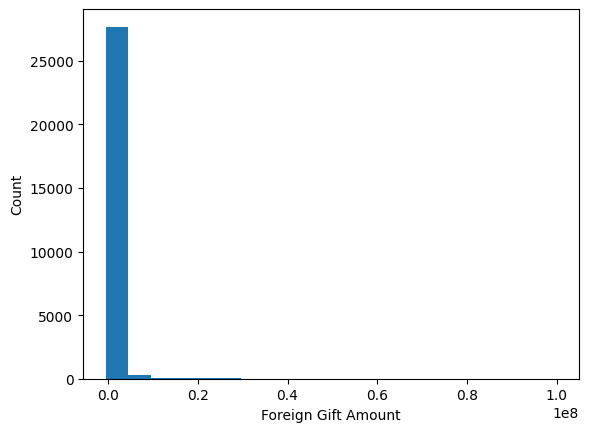

In [14]:
#Q2-2 
df["Foreign Gift Amount"].hist(bins=20, grid=False)
plt.xlabel("Foreign Gift Amount")
plt.ylabel("Count")
plt.show()

Q2-2 Answer: Most of the gifts are small with a few very large ones. Almost all of them are in the first bar, showing that most gifts are under $5 million. The axis covers all the way to $100 million, which appears to be the largest gift. As such, the histogram is extremely right skewed, and not really easy to read.

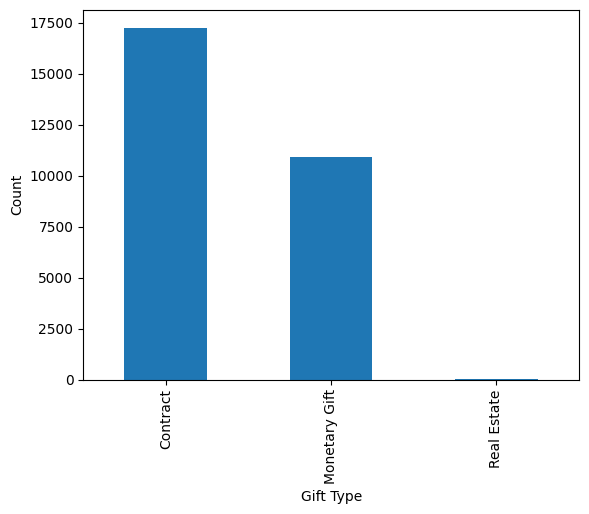

Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64

In [15]:
#Q2-3
df["Gift Type"].value_counts().plot(kind="bar")
plt.xlabel("Gift Type")
plt.ylabel("Count")
plt.show()

df["Gift Type"].value_counts(normalize=True)

Q2-3 Answer: Contracts make up about 61.2% of the gifts and monetary gifts make up about 38.75%. Real estate has very few records, which is about 0.04%.

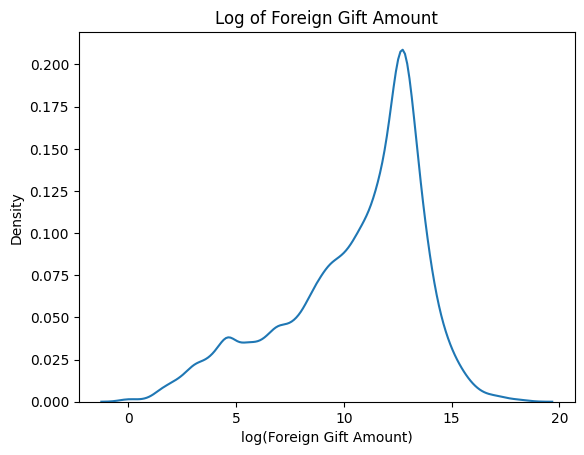

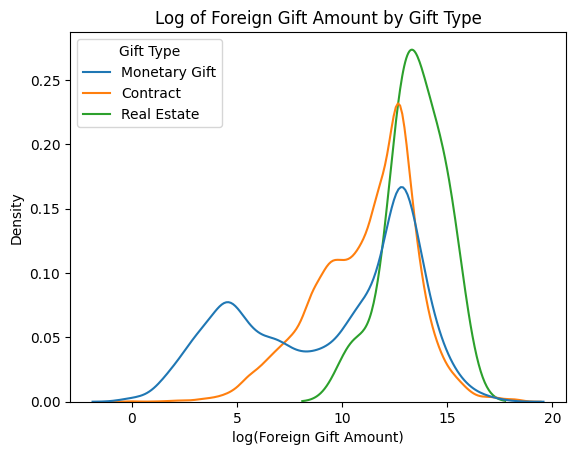

In [16]:
# Q2-4
transformation = df[df["Foreign Gift Amount"] > 0].copy()
transformation["log_amount"] = np.log(transformation["Foreign Gift Amount"])

sns.kdeplot(data=transformation, x="log_amount")
plt.title("Log of Foreign Gift Amount")
plt.xlabel("log(Foreign Gift Amount)")
plt.show()

sns.kdeplot(
    data=transformation,
    x="log_amount",
    hue="Gift Type",
    common_norm=False
)
plt.title("Log of Foreign Gift Amount by Gift Type")
plt.xlabel("log(Foreign Gift Amount)")
plt.show()

Q2-4 Answer: Taking the log makes the data much easier to read. The density plot shows one big peak around 13, a long tail to the left, and a peak around 4.5 where the smaller gifts are. When split by gift type, contracts have one large peak around 13, while monetary gifts are split into two peaks, one around 4.5 and another around 13. This shows that monetary gifts are either very small or fairly large with less in between. Real estate also has one main peak around 13–14 and is more concentrated in the higher gift amounts, although there are very few real estate observations.

In [17]:
#Q2-5
df.groupby("Country of Giftor")["Foreign Gift Amount"].count().sort_values(ascending=False).head(15)

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64

In [18]:
#gift amounts for each country of giftor
df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(15)

Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64

Q2-5 Answer: By number of gifts, the top 15 countries are England, China, Canada, Japan, Switzerland, Saudi Arabia, France, Germany, Hong Kong, South Korea, Qatar, the Netherlands, Korea, India, and Taiwan. 
By total amount given, the top 15 are Qatar, England, China, Saudi Arabia, Bermuda, Canada, Hong Kong, Japan, Switzerland, India, Germany, the United Arab Emirates, France, Singapore, and Australia.

In [19]:
#Q2-6
df.groupby("Giftor Name")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(15)

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64

Q2-6 Answer: The top three giftors are Qatar Foundation at about $1.17 billion, Qatar Foundation/Qatar National Res at about $796 million, and Qatar Foundation for Education at about $374 million. These are all organizations from Qatar. 

### *Reflection on AI assistance
In your own words without generative AI.

Using ChatGPT for phase 2 was very helpful because it helped me notice smaller mistakes in my notebook. In Question 1.4, I originally used g(x)=x^2, but ChatGPT pointed out that this function is not non-decreasing for all real numbers. I changed it to g(x)=x^3, which gave me a better example while still showing the same idea. Chat also highlighted using common_norm=False for the plot in Question 2.4. This was helpful because it made the different gift types easier to compare, especially when real estate had very few observations compared to the other two categories. I was happy with the ChatGPT responses and suggestions this time because most of them were simple changes that made my original work more accurate or easier to read. One limitation I still noticed was that the real estate KDE is based on very few observations, so even with common_norm=False, it would be hard to come to any meaningful conclusion. I also liked the suggestion to use Markdown for my handwritten images because it made the notebook look cleaner. I still checked the changes myself by rerunning the code, looking at the plots, and checking the values. 